Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
params = [{'mu0': 23.434150704266614, 'lambda_val': 64.3162749846959, 'delta': 3.1592068430254803, 'sigma0': 4.92757661734069, 'sigmav': 0.15907131970926605, 'alpha': 26.39999999982333, 'beta': 0.0, 'halted': 0.20000000000011664},
{'mu0': 23.223640656458386, 'lambda_val': 65.53859609213828, 'delta': 0.6777583299551883, 'sigma0': 4.768934477979566, 'sigmav': 0.15728767175563638, 'alpha': 26.4, 'beta': 0.0, 'halted': 0.20000000000007598},
{'mu0': 23.086905402260452, 'lambda_val': 65.74833466551964, 'delta': 2.411744931709265e-09, 'sigma0': 4.781732594963203, 'sigmav': 0.15468800341179562, 'alpha': 25.940372391464052, 'beta': 0.0, 'halted': 0.20000000000046728},
{'mu0': 22.959675334316962, 'lambda_val': 65.64950106883194, 'delta': 3.4275589509809516e-12, 'sigma0': 4.815834368103637, 'sigmav': 0.15253537645711146, 'alpha': 24.572297117018664, 'beta': 0.0, 'halted': 0.20000000000003404},
{'mu0': 22.828448204530225, 'lambda_val': 65.56929201034603, 'delta': 1.349126651509029e-10, 'sigma0': 4.832894933714682, 'sigmav': 0.15070874015616953, 'alpha': 23.37830522881464, 'beta': 0.0, 'halted': 0.20000000000180734},
{'mu0': 22.702972506143045, 'lambda_val': 65.50116423542741, 'delta': 9.05682966104966e-11, 'sigma0': 4.8481980487205565, 'sigmav': 0.14907574089259462, 'alpha': 22.17959821899469, 'beta': 0.0, 'halted': 0.20000000000026358},
{'mu0': 22.589710190520186, 'lambda_val': 65.44509485095338, 'delta': 5.3940795328059156e-11, 'sigma0': 4.8540971927876395, 'sigmav': 0.14764610942359604, 'alpha': 20.935649371602928, 'beta': 0.0, 'halted': 0.2000000000010445},
{'mu0': 22.481031647458103, 'lambda_val': 65.40374905163296, 'delta': 3.596527161716581e-11, 'sigma0': 4.884239356021261, 'sigmav': 0.14626735511797218, 'alpha': 19.657868918431223, 'beta': 0.0, 'halted': 0.2000000000016468},
{'mu0': 22.36969530497982, 'lambda_val': 65.37180057340765, 'delta': 0.0, 'sigma0': 4.903500530188769, 'sigmav': 0.1450191941879263, 'alpha': 18.458105482970424, 'beta': 0.0, 'halted': 0.20000000000027796},
{'mu0': 22.286961352166514, 'lambda_val': 65.32553033384423, 'delta': 1.4055619901256802e-07, 'sigma0': 4.912179434342308, 'sigmav': 0.14378137478197034, 'alpha': 17.60000169944999, 'beta': 0.0, 'halted': 0.20000000033576593},
{'mu0': 22.188793530356932, 'lambda_val': 65.28016290131012, 'delta': 3.0159878457173714e-09, 'sigma0': 4.915924386214153, 'sigmav': 0.14272848986174663, 'alpha': 17.600000006828942, 'beta': 0.0, 'halted': 0.20000000041522353},
{'mu0': 22.100653735567573, 'lambda_val': 65.25423804678836, 'delta': 2.154338937032645e-08, 'sigma0': 4.914171704919205, 'sigmav': 0.14181632796238608, 'alpha': 17.600003384065534, 'beta': 0.0, 'halted': 0.2000000001648145},
{'mu0': 22.011834669942935, 'lambda_val': 65.24341437058459, 'delta': 1.1393018746085047e-09, 'sigma0': 4.908135845428454, 'sigmav': 0.1411017768879511, 'alpha': 17.60000006443454, 'beta': 0.0, 'halted': 0.20000000001561863},
{'mu0': 21.941101583804453, 'lambda_val': 65.22866900781534, 'delta': 1.6775488818075915e-08, 'sigma0': 4.919796495586084, 'sigmav': 0.14035273904043305, 'alpha': 17.600001007605172, 'beta': 0.0, 'halted': 0.20000000134645113},
{'mu0': 21.876856292823447, 'lambda_val': 65.21927441867956, 'delta': 2.737097614687426e-08, 'sigma0': 4.920076628065203, 'sigmav': 0.13969643822170846, 'alpha': 17.600000040411302, 'beta': 0.0, 'halted': 0.20000000520613365},
{'mu0': 21.80569786188054, 'lambda_val': 65.21622651704863, 'delta': 3.1377506536838966e-08, 'sigma0': 4.9219455863593335, 'sigmav': 0.1391297916629385, 'alpha': 17.600000005091346, 'beta': 0.0, 'halted': 0.20000000000475826},
{'mu0': 21.73979310915227, 'lambda_val': 65.21892051381249, 'delta': 1.3101831111129215e-08, 'sigma0': 4.92384603130043, 'sigmav': 0.13865334469880503, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.2000000003878447},
{'mu0': 21.68849575047436, 'lambda_val': 65.21742899807612, 'delta': 7.87387896817183e-10, 'sigma0': 4.917311702093292, 'sigmav': 0.13823040841609394, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.20000000001332424},
{'mu0': 21.648036285424702, 'lambda_val': 65.21703406112219, 'delta': 1.5515581299290266e-07, 'sigma0': 4.92236065476073, 'sigmav': 0.13783357270439864, 'alpha': 17.600000253902017, 'beta': 0.0, 'halted': 0.20000000042923455},
{'mu0': 21.611577253054925, 'lambda_val': 65.21634314628204, 'delta': 7.343206017956819e-10, 'sigma0': 4.9109862259275765, 'sigmav': 0.13748264584341707, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.20000000002422602},
{'mu0': 21.58947714432331, 'lambda_val': 65.21525894167769, 'delta': 0.0, 'sigma0': 4.910955841879016, 'sigmav': 0.13715685157415664, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.20000000044932664},
{'mu0': 21.568356639765724, 'lambda_val': 65.21740719067895, 'delta': 9.017158908927568e-08, 'sigma0': 4.917386942950614, 'sigmav': 0.13685989777220983, 'alpha': 17.600000147027796, 'beta': 0.0, 'halted': 0.2000000000222854},
{'mu0': 21.545271586214376, 'lambda_val': 65.22201279554571, 'delta': 1.4966366305364636e-08, 'sigma0': 4.9247400539277955, 'sigmav': 0.13659035016847632, 'alpha': 17.600000158804193, 'beta': 0.0, 'halted': 0.2000000000257714},
{'mu0': 21.523395431361685, 'lambda_val': 65.23051977281472, 'delta': 0.0, 'sigma0': 4.936395026533221, 'sigmav': 0.1363337637022412, 'alpha': 17.600000015567744, 'beta': 0.0, 'halted': 0.2000000000011527},
{'mu0': 21.34024840472184, 'lambda_val': 65.13794613890474, 'delta': 4.768279504736434e-09, 'sigma0': 4.857062492220949, 'sigmav': 0.13612139948802315, 'alpha': 26.4, 'beta': 0.0, 'halted': 0.2103797286332259},
{'mu0': 21.465555421235592, 'lambda_val': 65.24916335030663, 'delta': 1.1857962722640118e-08, 'sigma0': 4.9642235334279405, 'sigmav': 0.13593857604895632, 'alpha': 18.901821411856602, 'beta': 0.0, 'halted': 0.20000000001059873},
{'mu0': 21.433518131101046, 'lambda_val': 65.29849577796861, 'delta': 1.8799326771446893e-08, 'sigma0': 4.963700563509615, 'sigmav': 0.13598746482717688, 'alpha': 17.600000766479212, 'beta': 0.0, 'halted': 0.20000000003004237},
{'mu0': 21.410403200729625, 'lambda_val': 65.29581685138196, 'delta': 2.1245996509265005e-06, 'sigma0': 4.971253756183922, 'sigmav': 0.1357717624355418, 'alpha': 17.600000032338873, 'beta': 0.0, 'halted': 0.20000000005095714},
{'mu0': 21.39288807759054, 'lambda_val': 65.29574849243716, 'delta': 2.1382851758375652e-08, 'sigma0': 4.972924561911981, 'sigmav': 0.1355908398648492, 'alpha': 17.600000020268006, 'beta': 0.0, 'halted': 0.2000000000575891},
{'mu0': 21.37194825920958, 'lambda_val': 65.29764773210074, 'delta': 9.440740266771038e-08, 'sigma0': 4.973426147659142, 'sigmav': 0.13542642948452796, 'alpha': 17.60000001751576, 'beta': 0.0, 'halted': 0.20000000583922942},
{'mu0': 21.355342987134968, 'lambda_val': 65.29644643388835, 'delta': 5.860137826038388e-07, 'sigma0': 4.975085405092905, 'sigmav': 0.13527949627682395, 'alpha': 17.600000033465122, 'beta': 0.0, 'halted': 0.20000000025183728},
{'mu0': 21.34306693080977, 'lambda_val': 65.29301417367475, 'delta': 9.59040649107664e-09, 'sigma0': 4.970285863278193, 'sigmav': 0.13514017153594154, 'alpha': 17.600000001181762, 'beta': 0.0, 'halted': 0.20000000052123162},
{'mu0': 21.328214182518657, 'lambda_val': 65.29220839083366, 'delta': 2.8502314836552367e-08, 'sigma0': 4.9612733315233335, 'sigmav': 0.1350462969415628, 'alpha': 17.600000702425298, 'beta': 0.0, 'halted': 0.2000000001087925},
{'mu0': 21.315249483564568, 'lambda_val': 65.29118035706463, 'delta': 5.003152812667114e-09, 'sigma0': 4.960525015426484, 'sigmav': 0.13495563089480267, 'alpha': 17.600000149890683, 'beta': 0.0, 'halted': 0.20000002220409294},
{'mu0': 21.2983544945359, 'lambda_val': 65.29264179006088, 'delta': 4.012823326654144e-09, 'sigma0': 4.959051112196689, 'sigmav': 0.13489681148048363, 'alpha': 17.600007271768447, 'beta': 0.0, 'halted': 0.20000000079828822},
{'mu0': 21.275468830039586, 'lambda_val': 65.29954305580213, 'delta': 3.3057518263609345e-09, 'sigma0': 4.947879149753085, 'sigmav': 0.13488581027886787, 'alpha': 17.600000075576418, 'beta': 0.0, 'halted': 0.2000000001561636},
{'mu0': 21.249914552544823, 'lambda_val': 65.30641134267596, 'delta': 4.901508534510079e-07, 'sigma0': 4.9478193061571725, 'sigmav': 0.13484699572326986, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.20000000144988106},
{'mu0': 21.231763318727836, 'lambda_val': 65.30964221434041, 'delta': 1.0327430497700303e-07, 'sigma0': 4.947550538305407, 'sigmav': 0.1348005091027758, 'alpha': 17.60000002449427, 'beta': 0.0, 'halted': 0.20000000058673728},
{'mu0': 21.212786345749844, 'lambda_val': 65.30978174856611, 'delta': 1.68278168535294e-09, 'sigma0': 4.943150764069324, 'sigmav': 0.13473601868689683, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.2},
{'mu0': 21.192227142028223, 'lambda_val': 65.31000375099029, 'delta': 1.2174149492980969e-08, 'sigma0': 4.939035650474126, 'sigmav': 0.13468067666546868, 'alpha': 17.600001342882194, 'beta': 0.0, 'halted': 0.20000000012132813},
{'mu0': 21.160770788336762, 'lambda_val': 65.31850972976346, 'delta': 3.920170018832996e-09, 'sigma0': 4.926615264436741, 'sigmav': 0.13470989942771566, 'alpha': 17.60000001809304, 'beta': 0.0, 'halted': 0.2000000005189552},
{'mu0': 21.135199682276344, 'lambda_val': 65.32486877989857, 'delta': 0.0, 'sigma0': 4.918706236139243, 'sigmav': 0.1347155391381964, 'alpha': 17.60000006441203, 'beta': 0.0, 'halted': 0.20000000040705213},
{'mu0': 21.11427168563624, 'lambda_val': 65.32919054236187, 'delta': 2.1176806382914686e-08, 'sigma0': 4.908992309501683, 'sigmav': 0.13471233793756715, 'alpha': 17.600000031345083, 'beta': 0.0, 'halted': 0.20000000088863243},
{'mu0': 21.100603105060188, 'lambda_val': 65.33089996727293, 'delta': 9.718120376635165e-09, 'sigma0': 4.89811744879783, 'sigmav': 0.13468998256660253, 'alpha': 17.600000028128765, 'beta': 0.0, 'halted': 0.20000000003468354},
{'mu0': 21.08570750525935, 'lambda_val': 65.33367094412804, 'delta': 3.9532970057675834e-08, 'sigma0': 4.891760516645586, 'sigmav': 0.13467340095210592, 'alpha': 17.600000050336625, 'beta': 0.0, 'halted': 0.2000000000059614},
{'mu0': 21.071265523294628, 'lambda_val': 65.33724546059226, 'delta': 9.827822215435203e-09, 'sigma0': 4.887362184378736, 'sigmav': 0.13464377653837234, 'alpha': 17.600000013140573, 'beta': 0.0, 'halted': 0.20000000135750798},
{'mu0': 21.05630540704456, 'lambda_val': 65.34284032411946, 'delta': 2.7861519898304262e-09, 'sigma0': 4.882216423362049, 'sigmav': 0.13463281058499532, 'alpha': 17.6000000838685, 'beta': 0.0, 'halted': 0.20000000003159943},
{'mu0': 21.041849482347196, 'lambda_val': 65.3475427420372, 'delta': 1.1779846944331133e-07, 'sigma0': 4.878428079855514, 'sigmav': 0.13457115374228112, 'alpha': 17.600000173147173, 'beta': 0.0, 'halted': 0.20000000051087358},
{'mu0': 21.035967587939236, 'lambda_val': 65.3471817409077, 'delta': 6.64908898009296e-10, 'sigma0': 4.878202349691614, 'sigmav': 0.13448288301886735, 'alpha': 17.60000019470777, 'beta': 0.0, 'halted': 0.2000000002036804},
{'mu0': 21.023324910721406, 'lambda_val': 65.35187342848931, 'delta': 1.0351604621775426e-08, 'sigma0': 4.876916679517169, 'sigmav': 0.13444217623897292, 'alpha': 17.60000000987575, 'beta': 0.0, 'halted': 0.20000000005990626},
{'mu0': 21.014675247368373, 'lambda_val': 65.35470428399123, 'delta': 7.163240633721316e-09, 'sigma0': 4.870706529585879, 'sigmav': 0.13439825085204002, 'alpha': 17.60000001353145, 'beta': 0.0, 'halted': 0.20000000000046328},
{'mu0': 21.005641870563075, 'lambda_val': 65.35599343568536, 'delta': 6.3529989079359885e-09, 'sigma0': 4.869535676180349, 'sigmav': 0.13432454851842068, 'alpha': 17.600000005020753, 'beta': 0.0, 'halted': 0.20000000096938983},
{'mu0': 20.998687658715966, 'lambda_val': 65.35896977708919, 'delta': 1.0450375902852642e-07, 'sigma0': 4.870592898024688, 'sigmav': 0.13426162554696272, 'alpha': 17.600001475262392, 'beta': 0.0, 'halted': 0.20000000010372135},
{'mu0': 20.993662504862954, 'lambda_val': 65.35933082890227, 'delta': 7.04715434980894e-09, 'sigma0': 4.8744759087836975, 'sigmav': 0.13420211738694804, 'alpha': 17.600000422665204, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.98935131377082, 'lambda_val': 65.36134881568503, 'delta': 6.109534364356302e-07, 'sigma0': 4.875069541024093, 'sigmav': 0.13416053019189905, 'alpha': 17.600000084121355, 'beta': 0.0, 'halted': 0.2000000001778009},
{'mu0': 20.98597293583388, 'lambda_val': 65.36369679993217, 'delta': 5.909485981232234e-10, 'sigma0': 4.875311752278861, 'sigmav': 0.13414114773981634, 'alpha': 17.600000005932824, 'beta': 0.0, 'halted': 0.20000000006271854},
{'mu0': 20.985454290284643, 'lambda_val': 65.36287472252104, 'delta': 7.335159633488894e-09, 'sigma0': 4.877094924953111, 'sigmav': 0.13409874729848792, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.2000000002494669},
{'mu0': 20.984774263102807, 'lambda_val': 65.36332844577356, 'delta': 0.0, 'sigma0': 4.878643958034161, 'sigmav': 0.1340786520795878, 'alpha': 17.60000000626519, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.98317365882753, 'lambda_val': 65.36304079186897, 'delta': 2.6361614129079494e-08, 'sigma0': 4.8789200922791185, 'sigmav': 0.13406553019873907, 'alpha': 17.60000001808868, 'beta': 0.0, 'halted': 0.20000000000168144},
{'mu0': 20.982084973844778, 'lambda_val': 65.36249985855963, 'delta': 2.6949898043238e-08, 'sigma0': 4.8787572058957, 'sigmav': 0.13405576646653566, 'alpha': 17.600000002122876, 'beta': 0.0, 'halted': 0.2000000202373705},
{'mu0': 20.981336266302996, 'lambda_val': 65.36212577362977, 'delta': 3.474302508450867e-09, 'sigma0': 4.878830874520965, 'sigmav': 0.134045976946022, 'alpha': 17.600000002689015, 'beta': 0.0, 'halted': 0.2000000001315092},
{'mu0': 20.980363654338223, 'lambda_val': 65.36383015223731, 'delta': 5.859668618820974e-09, 'sigma0': 4.877136098283433, 'sigmav': 0.13404567439730414, 'alpha': 17.600000149717758, 'beta': 0.0, 'halted': 0.2000000000263397},
{'mu0': 20.97963702632243, 'lambda_val': 65.36539719895089, 'delta': 9.910203164568611e-11, 'sigma0': 4.87622116879491, 'sigmav': 0.13404339670130916, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.200000000359363},
{'mu0': 20.979387110962204, 'lambda_val': 65.36469319152265, 'delta': 4.269467483065588e-07, 'sigma0': 4.877167061710887, 'sigmav': 0.13403262508720715, 'alpha': 17.600000026351857, 'beta': 0.0, 'halted': 0.20000000031786758},
{'mu0': 20.978778875718607, 'lambda_val': 65.36607424863934, 'delta': 2.4001136905964035e-08, 'sigma0': 4.876028092442844, 'sigmav': 0.13403304258773457, 'alpha': 17.6000000370099, 'beta': 0.0, 'halted': 0.2000000000090009},
{'mu0': 20.978296950310217, 'lambda_val': 65.36730565234124, 'delta': 0.0, 'sigma0': 4.875354119504003, 'sigmav': 0.13403209783473585, 'alpha': 17.600000216279177, 'beta': 0.0, 'halted': 0.20000000000068918},
{'mu0': 20.978731405279394, 'lambda_val': 65.3654161591106, 'delta': 5.5913109182295034e-08, 'sigma0': 4.87645263694413, 'sigmav': 0.13400885792542033, 'alpha': 17.600000013276066, 'beta': 0.0, 'halted': 0.20000000146626914},
{'mu0': 20.978510857909168, 'lambda_val': 65.36599284001935, 'delta': 3.1981184874489665e-10, 'sigma0': 4.875591395479128, 'sigmav': 0.13399744421320295, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.20000000000920654},
{'mu0': 20.970450005387434, 'lambda_val': 65.37142358333227, 'delta': 1.2230358153777004e-06, 'sigma0': 4.872604494744387, 'sigmav': 0.13401448776681024, 'alpha': 17.600011549234104, 'beta': 0.0, 'halted': 0.2000000002035035},
{'mu0': 20.9656312979682, 'lambda_val': 65.3747830202608, 'delta': 5.856461555611415e-09, 'sigma0': 4.8695577769442995, 'sigmav': 0.1340204670200401, 'alpha': 17.600000293869527, 'beta': 0.0, 'halted': 0.20000000019724495},
{'mu0': 20.95621216308755, 'lambda_val': 65.3777555529146, 'delta': 2.951919363327407e-08, 'sigma0': 4.866399783041871, 'sigmav': 0.13401666171147586, 'alpha': 17.600000003204293, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.940510167856907, 'lambda_val': 65.38307792364438, 'delta': 4.674975454649805e-08, 'sigma0': 4.86174761603341, 'sigmav': 0.1340277183589103, 'alpha': 17.600000047190754, 'beta': 0.0, 'halted': 0.20000000063396534},
{'mu0': 20.92877926382642, 'lambda_val': 65.38582284062241, 'delta': 2.2507826402389774e-08, 'sigma0': 4.853710486682676, 'sigmav': 0.13402971056484608, 'alpha': 17.600000157048576, 'beta': 0.0, 'halted': 0.20000000004450863},
{'mu0': 20.919943989823132, 'lambda_val': 65.38692824769689, 'delta': 1.77910591350649e-07, 'sigma0': 4.84951868940129, 'sigmav': 0.13400589120457757, 'alpha': 17.600000340889046, 'beta': 0.0, 'halted': 0.20000000003240614},
{'mu0': 20.91345196993501, 'lambda_val': 65.38660138967091, 'delta': 6.362594094171954e-08, 'sigma0': 4.852344304017754, 'sigmav': 0.1339773499219109, 'alpha': 17.600000158239112, 'beta': 0.0, 'halted': 0.20000004667400406},
{'mu0': 20.904643215447877, 'lambda_val': 65.39028067440216, 'delta': 2.514226034064282e-08, 'sigma0': 4.858736245374477, 'sigmav': 0.1339598381355503, 'alpha': 17.60000008799244, 'beta': 0.0, 'halted': 0.20000000002799323},
{'mu0': 20.90274803408043, 'lambda_val': 65.38887231475354, 'delta': 1.5693045674049587e-08, 'sigma0': 4.858160598512629, 'sigmav': 0.13392681588941993, 'alpha': 17.600000027116458, 'beta': 0.0, 'halted': 0.20000000035438167},
{'mu0': 20.903441067758976, 'lambda_val': 65.3867050176163, 'delta': 5.492531831009627e-08, 'sigma0': 4.853865371595326, 'sigmav': 0.13388999263578255, 'alpha': 17.600000019705973, 'beta': 0.0, 'halted': 0.20000000001036367},
{'mu0': 20.90109451041142, 'lambda_val': 65.38775287239923, 'delta': 9.006661468379036e-08, 'sigma0': 4.850505269964636, 'sigmav': 0.13387544126471493, 'alpha': 17.600001778401776, 'beta': 0.0, 'halted': 0.200000000054955},
{'mu0': 20.899203184130805, 'lambda_val': 65.38895180527507, 'delta': 8.330861057733603e-09, 'sigma0': 4.848387332060966, 'sigmav': 0.13386123030300906, 'alpha': 17.600001111907105, 'beta': 0.0, 'halted': 0.2000000000957322},
{'mu0': 20.89435837632945, 'lambda_val': 65.39173276797322, 'delta': 1.5455683199401626e-06, 'sigma0': 4.844231554431298, 'sigmav': 0.13386727973601753, 'alpha': 17.6000006138229, 'beta': 0.0, 'halted': 0.2000000022351296},
{'mu0': 20.890047453049817, 'lambda_val': 65.39322268253375, 'delta': 6.12606550731144e-09, 'sigma0': 4.837725055938809, 'sigmav': 0.13387660072953045, 'alpha': 17.60000011076115, 'beta': 0.0, 'halted': 0.200000034390874},
{'mu0': 20.890710605971968, 'lambda_val': 65.38997399218238, 'delta': 7.871005227763036e-06, 'sigma0': 4.837943107137746, 'sigmav': 0.13384664344483888, 'alpha': 17.600001547303926, 'beta': 0.0, 'halted': 0.2000000023831429},
{'mu0': 20.891418158241365, 'lambda_val': 65.38953616866087, 'delta': 4.871075525401724e-10, 'sigma0': 4.837973276603135, 'sigmav': 0.1338300352368968, 'alpha': 17.600000076911094, 'beta': 0.0, 'halted': 0.20000000001791318},
{'mu0': 20.891898248792867, 'lambda_val': 65.38952493797692, 'delta': 5.1578959291553345e-08, 'sigma0': 4.838282656759499, 'sigmav': 0.133816406994464, 'alpha': 17.60000031272708, 'beta': 0.0, 'halted': 0.20000000026412612},
{'mu0': 20.892184897390727, 'lambda_val': 65.38781529997902, 'delta': 1.3540903419020316e-09, 'sigma0': 4.840003890255189, 'sigmav': 0.13379581775960142, 'alpha': 17.600000008503137, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.89238442218207, 'lambda_val': 65.38828307338179, 'delta': 1.643063121748258e-09, 'sigma0': 4.839794810972764, 'sigmav': 0.13378941895834487, 'alpha': 17.600000484470836, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.89254000869643, 'lambda_val': 65.388814409747, 'delta': 4.912217636434268e-08, 'sigma0': 4.839792228950278, 'sigmav': 0.13378386259935263, 'alpha': 17.600000146229405, 'beta': 0.0, 'halted': 0.2000000000415023},
{'mu0': 20.89263533552799, 'lambda_val': 65.38936373941627, 'delta': 5.601532011204148e-09, 'sigma0': 4.839935190144541, 'sigmav': 0.13377911032096157, 'alpha': 17.600000035767913, 'beta': 0.0, 'halted': 0.2000000002712199},
{'mu0': 20.89269002629161, 'lambda_val': 65.38991510716677, 'delta': 3.116222977075107e-08, 'sigma0': 4.840099865060008, 'sigmav': 0.13377503064161508, 'alpha': 17.600000268421603, 'beta': 0.0, 'halted': 0.20000000068477167},
{'mu0': 20.892744298569976, 'lambda_val': 65.39036414262368, 'delta': 1.0848964249765216e-08, 'sigma0': 4.840204208852054, 'sigmav': 0.13377130259425032, 'alpha': 17.600000315163953, 'beta': 0.0, 'halted': 0.20000000018449454},
{'mu0': 20.8927692624926, 'lambda_val': 65.38901150112497, 'delta': 4.0429104257384663e-08, 'sigma0': 4.8416531891211925, 'sigmav': 0.13375858642156346, 'alpha': 17.600000027723638, 'beta': 0.0, 'halted': 0.20000000027468304},
{'mu0': 20.892811916002096, 'lambda_val': 65.38960969801666, 'delta': 1.7032476069435373e-08, 'sigma0': 4.841176120391719, 'sigmav': 0.13375871364581132, 'alpha': 17.60000051734658, 'beta': 0.0, 'halted': 0.2000000000101324},
{'mu0': 20.892805635601725, 'lambda_val': 65.39021338952688, 'delta': 3.7311010856379124e-09, 'sigma0': 4.840923913335146, 'sigmav': 0.1337582915047083, 'alpha': 17.600000084097253, 'beta': 0.0, 'halted': 0.2000000000245803},
{'mu0': 20.892797775185024, 'lambda_val': 65.39077254100846, 'delta': 0.0, 'sigma0': 4.840792071034771, 'sigmav': 0.133757878317877, 'alpha': 17.6, 'beta': 0.0, 'halted': 0.2000000000447627},
{'mu0': 20.89276529951032, 'lambda_val': 65.38940309275458, 'delta': 3.922350860757792e-09, 'sigma0': 4.842025579043497, 'sigmav': 0.13374790410595006, 'alpha': 17.60000002042868, 'beta': 0.0, 'halted': 0.20000000013325614},
{'mu0': 20.892777802281216, 'lambda_val': 65.39003464663006, 'delta': 8.318238492845199e-10, 'sigma0': 4.84143027814635, 'sigmav': 0.13374980037786094, 'alpha': 17.600000000025005, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.89357536370329, 'lambda_val': 65.38981475197392, 'delta': 0.00010955796170354772, 'sigma0': 4.842701154415865, 'sigmav': 0.13373891376243158, 'alpha': 17.600005108686076, 'beta': 0.0, 'halted': 0.2000000001071871},
{'mu0': 20.89333554439265, 'lambda_val': 65.39059871600912, 'delta': 1.7393985691507172e-08, 'sigma0': 4.841980224537863, 'sigmav': 0.13374290680931378, 'alpha': 17.600000004863183, 'beta': 0.0, 'halted': 0.2},
{'mu0': 20.893334023037536, 'lambda_val': 65.3909644943705, 'delta': 2.576401175967331e-08, 'sigma0': 4.841485254262888, 'sigmav': 0.1337437882845042, 'alpha': 17.600000018720735, 'beta': 0.0, 'halted': 0.20000054637316764}]

In [28]:
rns = [20.064864585092703,18.979922695220143,18.85891549132088,18.797339091931278,18.719789299588072,18.663957635825227,18.60236967991643,18.5446636938166,18.491579221911607,18.44703873128789,18.432692219095756,18.387326358738072,18.381439149903496,18.35510655095672,18.34907018862224,18.331817196815997,18.336945165789366,18.332743857467605,18.32918857630508,18.307496584623763,18.3085123338908,18.311559048253958,18.304181527362687,18.296756779518738,18.406179186719463,18.274085297361104,18.281057761865547,18.26693582057082,18.266344343817806,18.24320635689197,18.24602123086126,18.246136153081153,18.247291856226028,18.248303262863928,18.251809101268336,18.236053476473167,18.239991188600303,18.244123824261635,18.23917129131552,18.23973539205767,18.235699964773666,18.23833048346994,18.240145477777745,18.24567757805424,18.24449439035554,18.239349634439492,18.24303128188764,18.22609050741025,18.22596045685509,18.224976090999906,18.22775963463541,18.22521306946709,18.22435633737618,18.22958580459053,18.229294742256364,18.23219055334888,18.230322123285788,18.23225725421296,18.23555567252678,18.23608928742928,18.23647559694144,18.234886463943187,18.234911361326546,18.236860966220863,18.235208393129934,18.235189262077096,18.235452146949623,18.233697125329243,18.22844987481496,18.229087537561995,18.22199853203995,18.22305730800214,18.219270883449134,18.22146191677361,18.22124312729546,18.2203982179991,18.218544536649787,18.2073078965608,18.20563940648075,18.205997099748885,18.20637939327008,18.205268178288545,18.195308855094893,18.202723768547116,18.202528342665182,18.195058275080058,18.2025793824126,18.20245059088434,18.202346895148857,18.202272932793928,18.202214024327805,18.19482736345828,18.202384457803447,18.2022773387422,18.202202801497915,18.1948090251664,18.202371409139516,18.20226502880156,18.202114711872245]

In [36]:
len(rns), len(params_df)

(99, 100)

In [58]:
[print(c, end=', ') for c in params_df.columns]
0

mu0, lambda_val, delta, sigma0, sigmav, alpha, beta, halted, 

0

In [60]:
[p for p in params_df.iloc[-1]]

[20.893334023037536,
 65.3909644943705,
 2.576401175967331e-08,
 4.841485254262888,
 0.1337437882845042,
 17.600000018720735,
 0.0,
 0.20000054637316764]

Text(0.5, 0.98, 'Cell cycle parameter updates, 100 updates')

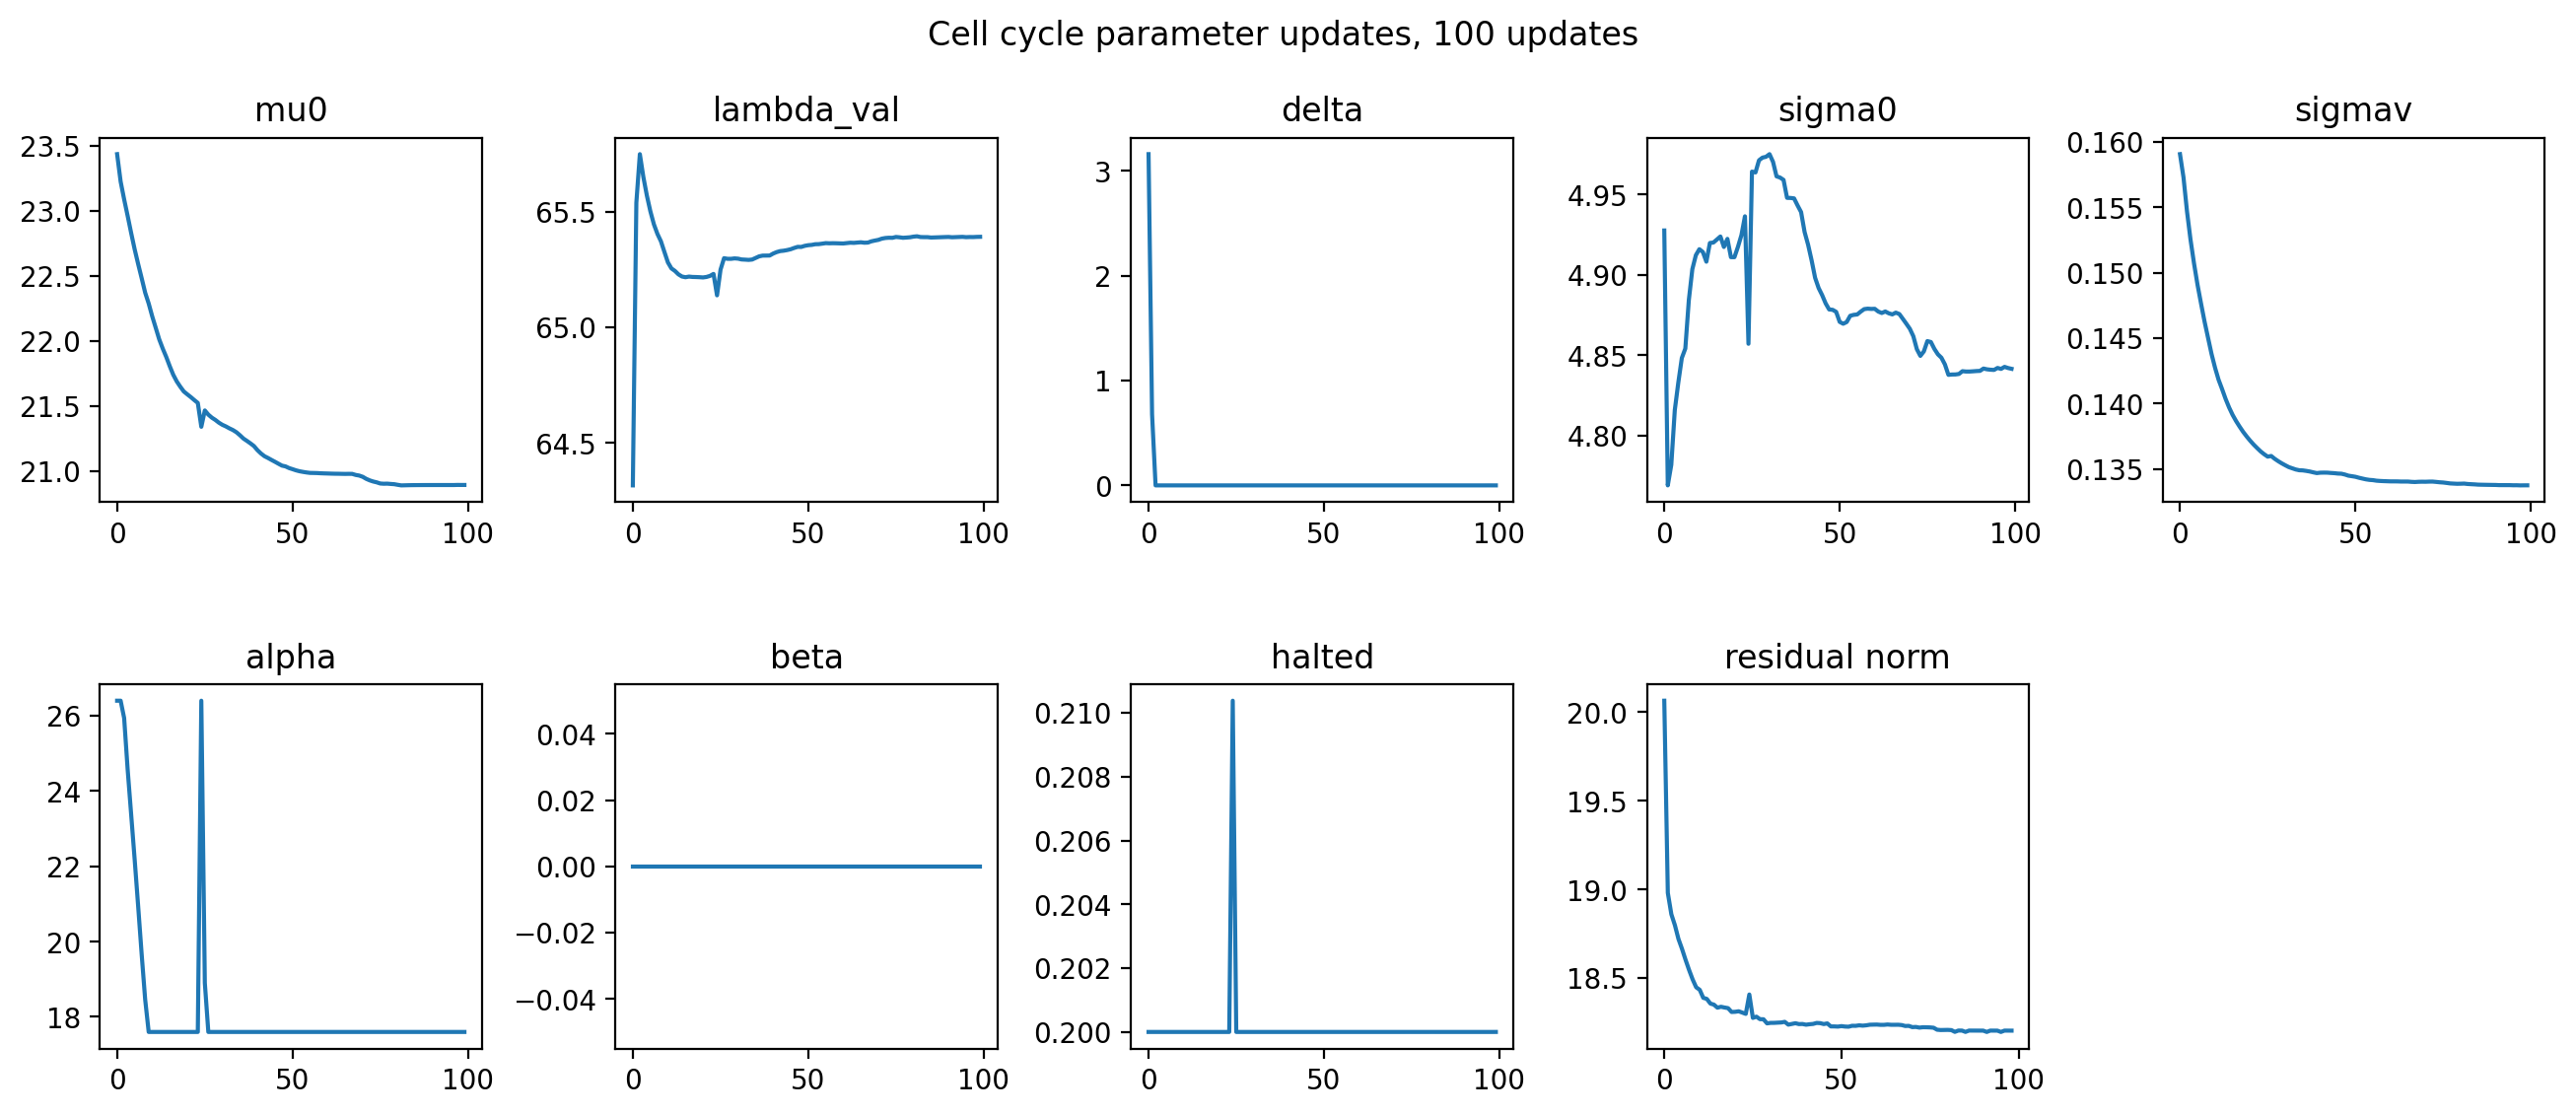

In [54]:
r, c = 2, 5

plt.figure(figsize=(16, 6))
params_df = pd.DataFrame(params)

for i, param in enumerate(params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(params_df[param])
    plt.title(param)
    
    
plt.subplot(r, c, r*c-1)
plt.plot(rns)
plt.title("residual norm")

plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle("Cell cycle parameter updates, 100 updates")